# Wavelet Source Detection for 3-D Spectral Cubes

Per-slice starlet (à trous IUWT) detection above diffuse emission.

**Strategy:**  
The starlet transform decomposes each spectral slice into fine detail bands (compact sources) and a coarse residual (diffuse emission). By thresholding only the fine scales we detect compact sources *above* the diffuse halo. Sources are found globally on the max-projected significance map, then measured per channel within Voronoi territories.

**Pipeline:**  
1. Per-channel significance maps (fine starlet scales, MAD noise, optional diffuse subtraction)  
2. Max-project → global significance  
3. `peak_local_max` → N source peaks  
4. Voronoi assignment → N territories  
5. Per-channel footprint = connected component at peak pixel within territory

## Imports

In [1]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path
from typing import NamedTuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass, label as nd_label
from skimage.measure import regionprops

## Multi-format cube loader

In [2]:
def load_cube(path: str | Path) -> np.ndarray:
    """Load a spectral cube from HDF5, FITS, .npy, or .npz.

    Always returns float32 (n_ch, H, W).
    """
    path = Path(path)
    suf = path.suffix.lower()

    if suf in (".h5", ".hdf5"):
        import h5py
        with h5py.File(path, "r") as f:
            cube = f["cube"][:].astype(np.float32)

    elif suf in (".fits", ".fit"):
        from astropy.io import fits
        with fits.open(path) as hdul:
            data = hdul[0].data
        if data is None:
            raise ValueError(f"No data in primary HDU of {path}")
        data = np.squeeze(data).astype(np.float32)
        if data.ndim == 2:
            data = data[np.newaxis]
        if data.ndim != 3:
            raise ValueError(f"Cannot interpret FITS array with shape {data.shape} as (n_ch,H,W)")
        cube = data

    elif suf == ".npy":
        cube = np.load(path).astype(np.float32)
        if cube.ndim == 2:
            cube = cube[np.newaxis]

    elif suf == ".npz":
        arch = np.load(path)
        if "cube" in arch:
            cube = arch["cube"].astype(np.float32)
        else:
            key = list(arch.keys())[0]
            cube = arch[key].astype(np.float32)

    else:
        raise ValueError(f"Unsupported file extension: {suf!r}. "
                         "Use .h5/.hdf5, .fits/.fit, .npy, or .npz")

    if cube.ndim != 3:
        raise ValueError(f"Loaded array has shape {cube.shape}; expected (n_ch, H, W)")

    np.nan_to_num(cube, copy=False, nan=0.0)
    return cube


def active_channels(cube: np.ndarray, threshold_frac: float = 0.05) -> list[int]:
    """Return indices of channels whose positive flux exceeds `threshold_frac` of the max.

    Uses only positive flux (clipped at zero) so noise-dominated channels don't inflate the total.
    """
    flux = np.nansum(np.clip(cube, 0.0, None), axis=(1, 2))
    thresh = threshold_frac * float(flux.max())
    return [int(i) for i in np.where(flux >= thresh)[0]]

In [5]:
CUBE_PATH = "/mnt/home/alahiry/data/mock_ifu/processed_cubes/clean_cube.npy"

cube = load_cube(CUBE_PATH)
n_ch, H, W = cube.shape
print(f"Cube shape: {cube.shape}  flux range [{cube.min():.3e}, {cube.max():.3e}]")

channel_list = active_channels(cube, threshold_frac=0.10)
print(f"Active channels: {len(channel_list)}  (ch {channel_list[0]}–{channel_list[-1]})")

Cube shape: (200, 500, 500)  flux range [-1.966e-19, 6.891e-02]
Active channels: 138  (ch 30–167)


In [19]:
from scipy.ndimage import gaussian_filter
from skimage.measure import label, regionprops
from skimage.feature import peak_local_max
import scarlet2 as sc

def wavelet_footprints_scarlet2(image, scales=4, k_sigma=2.3, use_scale=2, min_area=10, thresh=0.0):
    img = np.asarray(image, dtype=np.float32)
    #sigma = 1.4826 * np.median(np.abs(img - np.median(img))) + 1e-8
    coeffs = np.asarray(sc.wavelets.starlet_transform(img, scales=scales), dtype=np.float32)
    sigma = 1.4826 * np.median(
            np.abs(coeffs[0] - np.median(coeffs[0]))
        )
    detect = np.zeros_like(coeffs)
    for i in range(coeffs.shape[0] - 1):
        detect[i] = np.where(np.abs(coeffs[i]) > (k_sigma * sigma), coeffs[i], 0.0)
    detect[-1] = coeffs[-1]
    detect[detect < 0] = 0

    scale_idx = int(np.clip(use_scale - 1, 0, detect.shape[0] - 1))
    plane = detect[scale_idx]
    binary = plane > (k_sigma * sigma)    
    labeled = label(binary)
    regions = [r for r in regionprops(labeled, intensity_image=plane) if r.area >= min_area]

    peaks = []
    footprint_masks = []
    boxes = []
    for r in regions:
        y0, x0, y1, x1 = r.bbox
        patch = plane[y0:y1, x0:x1]
        if patch.size == 0:
            continue
        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        yy = y0 + py
        xx = x0 + px
        peaks.append((yy, xx))
        footprint_masks.append(labeled == r.label)
        boxes.append((y0, x0, y1, x1))

    if len(peaks) == 0:
        fallback = peak_local_max(img, min_distance=3, num_peaks=1, exclude_border=False)
        if len(fallback) > 0:
            yy, xx = fallback[0]
            peaks = [(int(yy), int(xx))]
            mask = np.zeros_like(img, dtype=bool)
            y0 = max(0, int(yy) - 2)
            y1 = min(img.shape[0], int(yy) + 3)
            x0 = max(0, int(xx) - 2)
            x1 = min(img.shape[1], int(xx) + 3)
            mask[y0:y1, x0:x1] = True
            footprint_masks = [mask]
            boxes = [(y0, x0, y1, x1)]

    footprint_img = np.zeros_like(img, dtype=np.float32)
    for mask in footprint_masks:
        footprint_img = np.maximum(footprint_img, mask.astype(np.float32))

    return detect, coeffs, footprint_img, footprint_masks, peaks, boxes

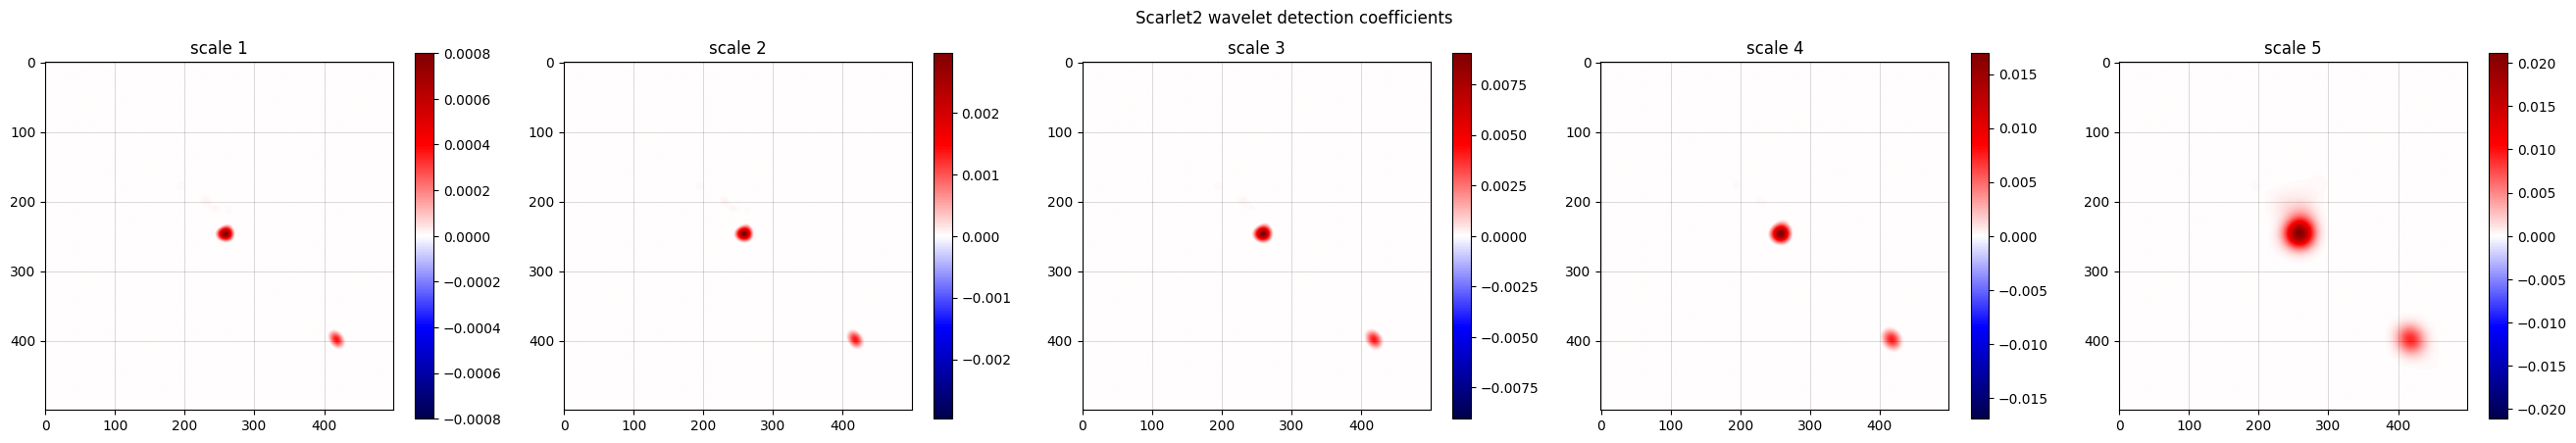

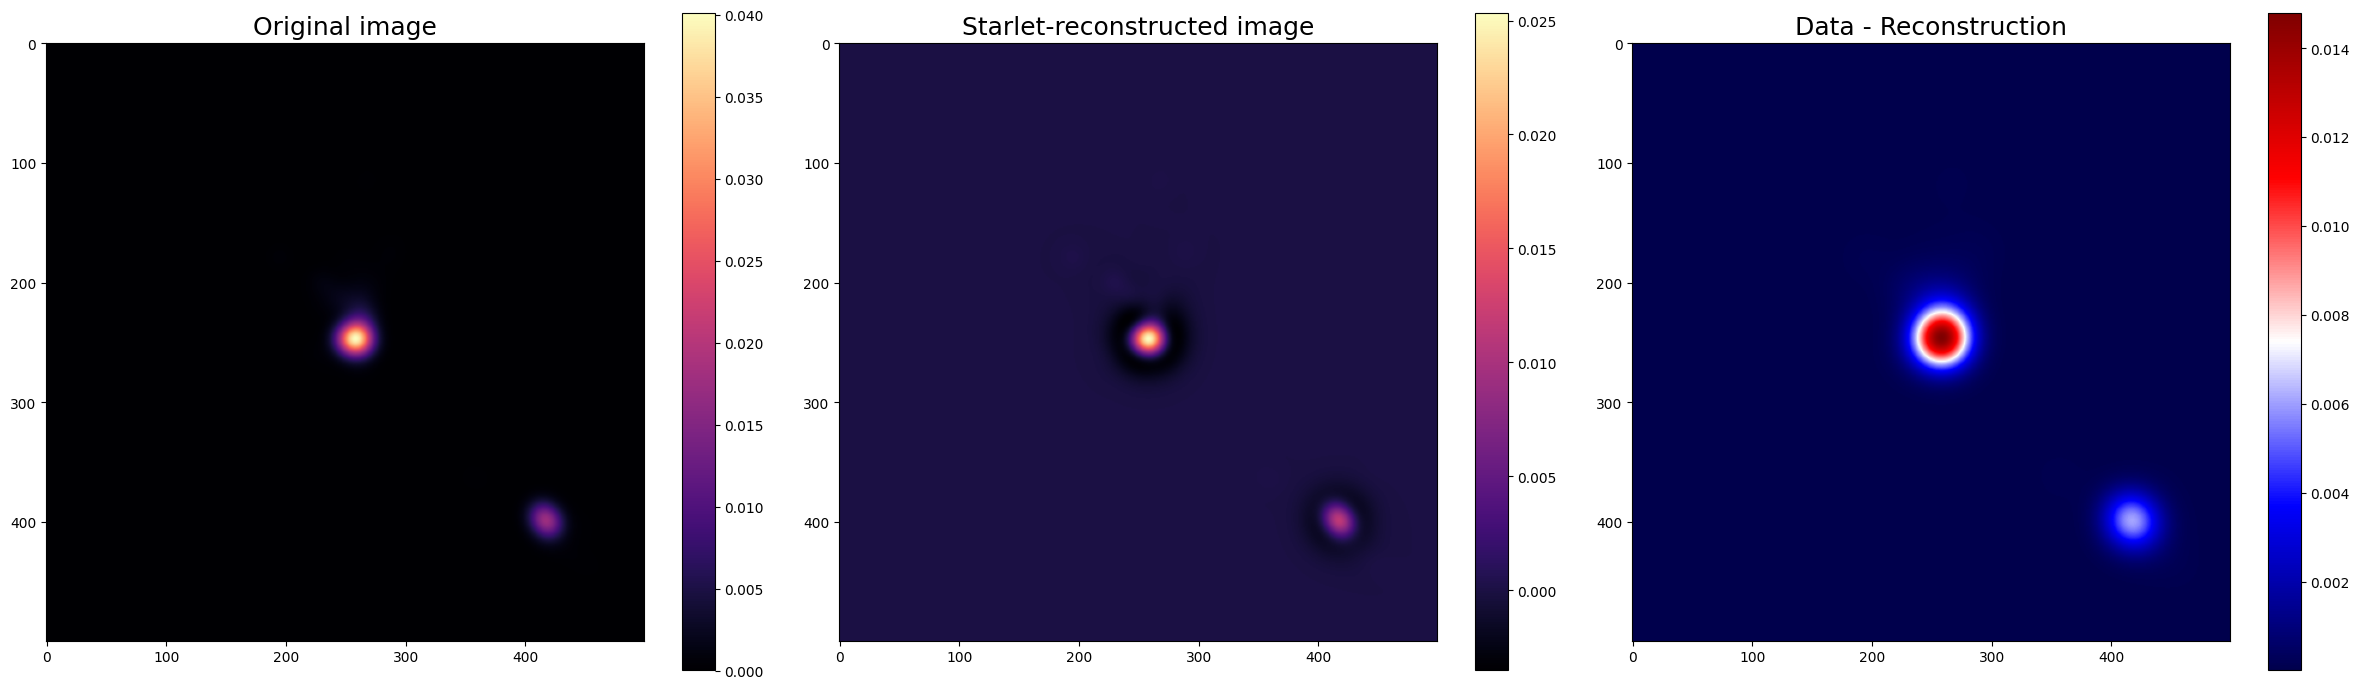

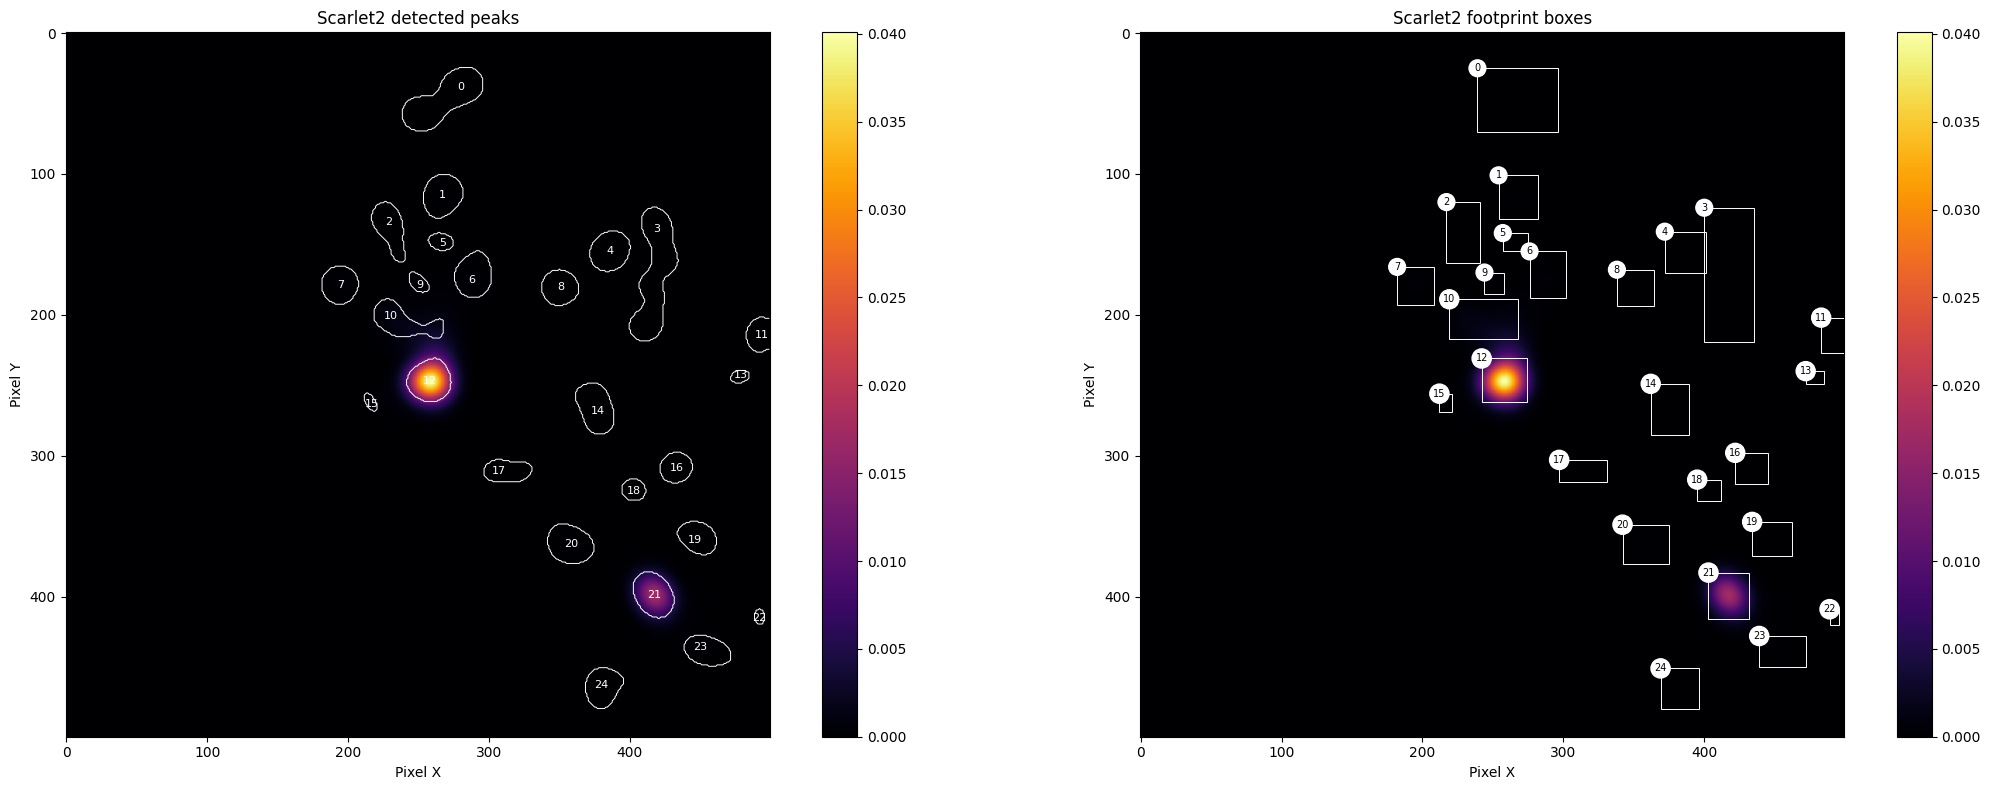

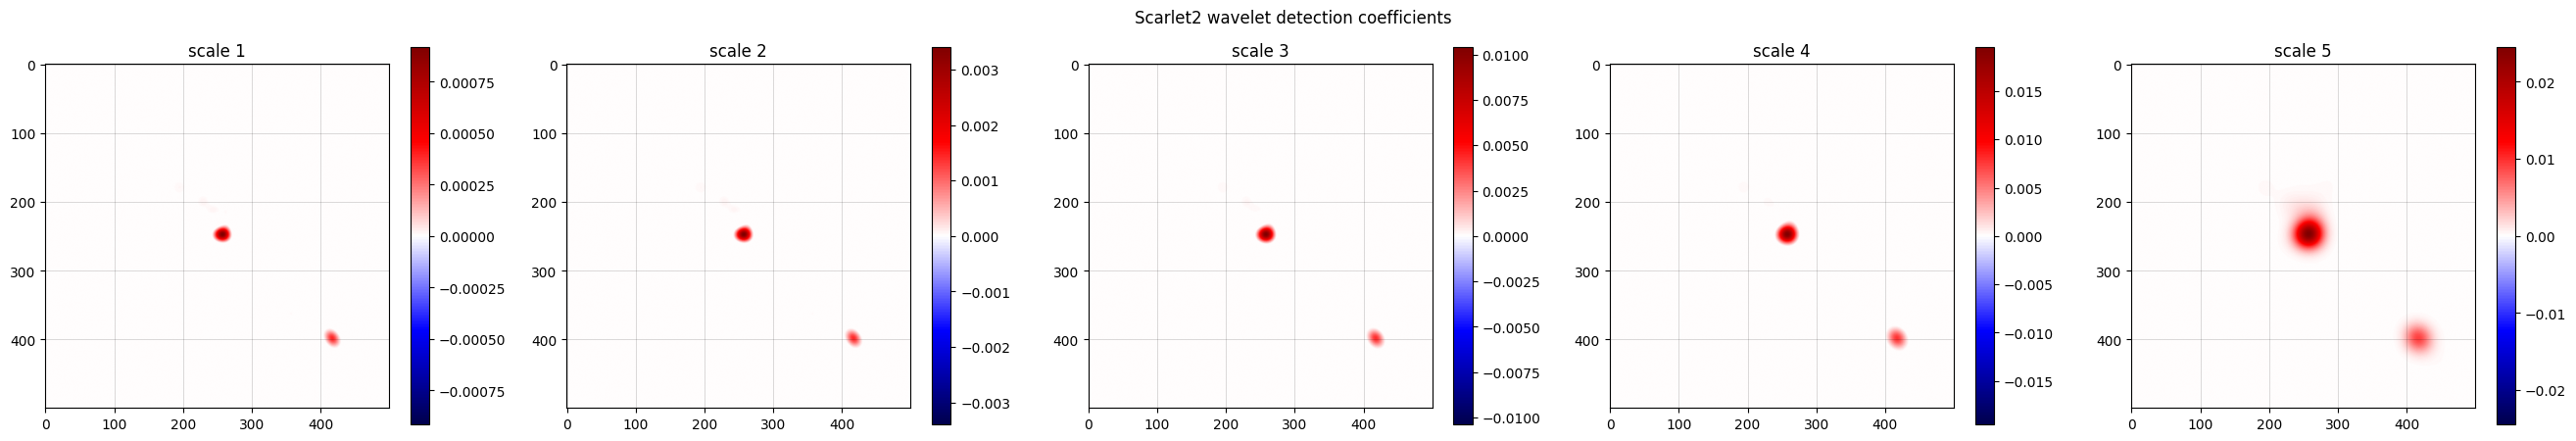

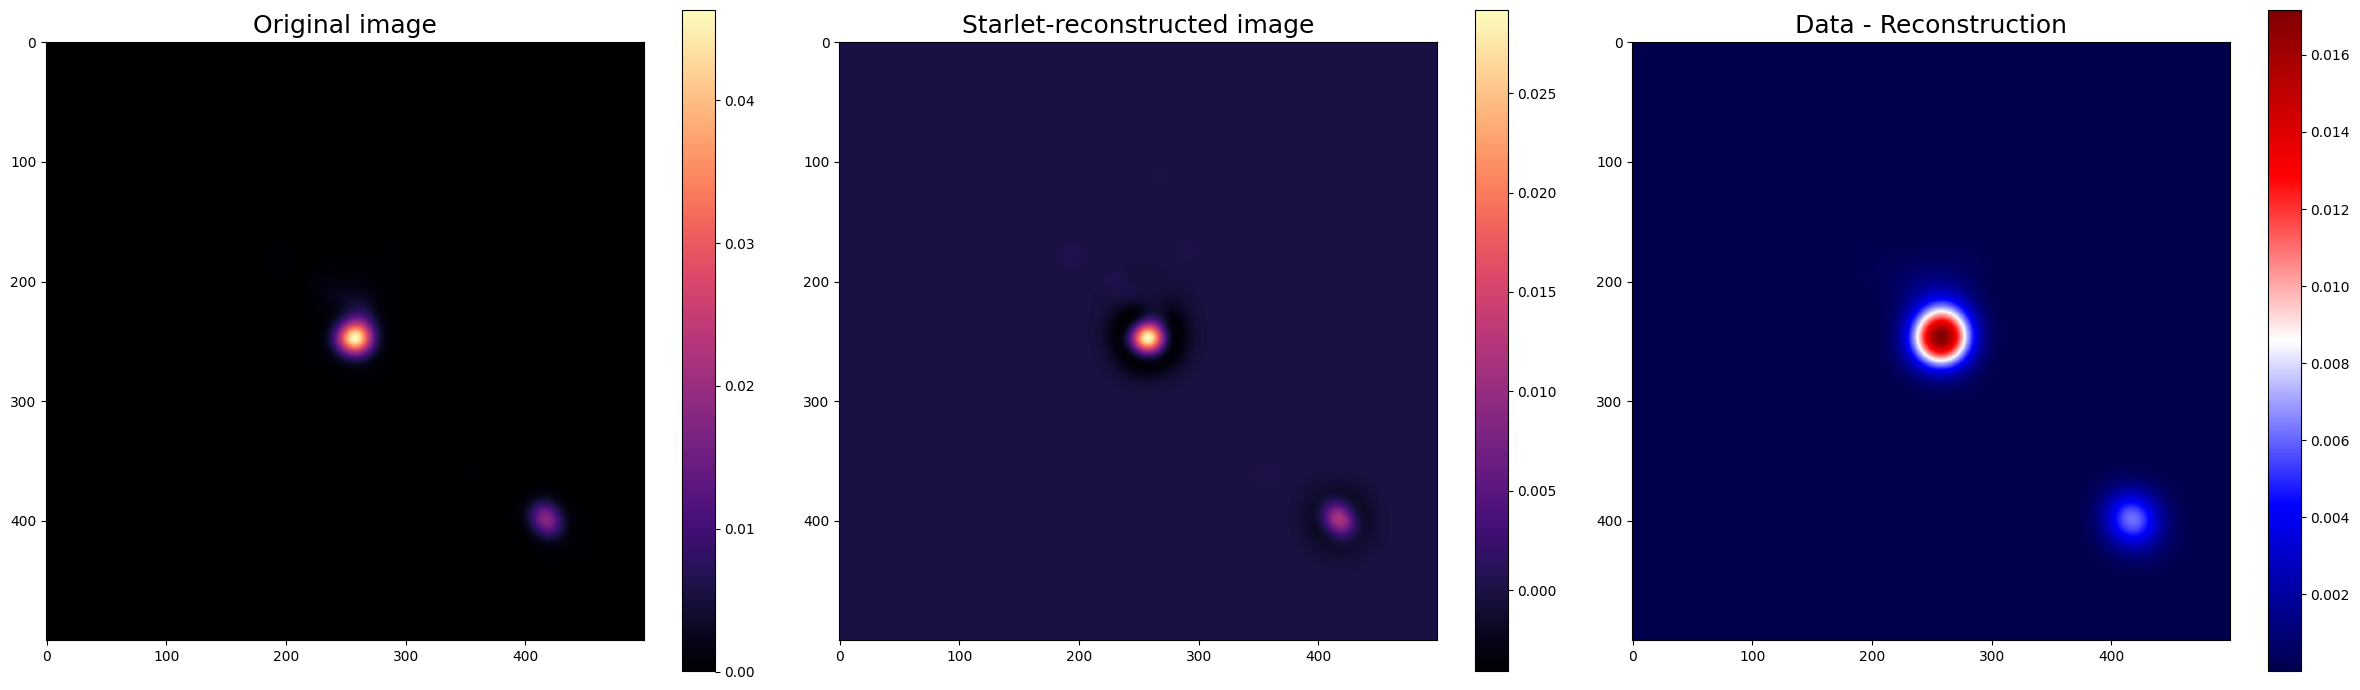

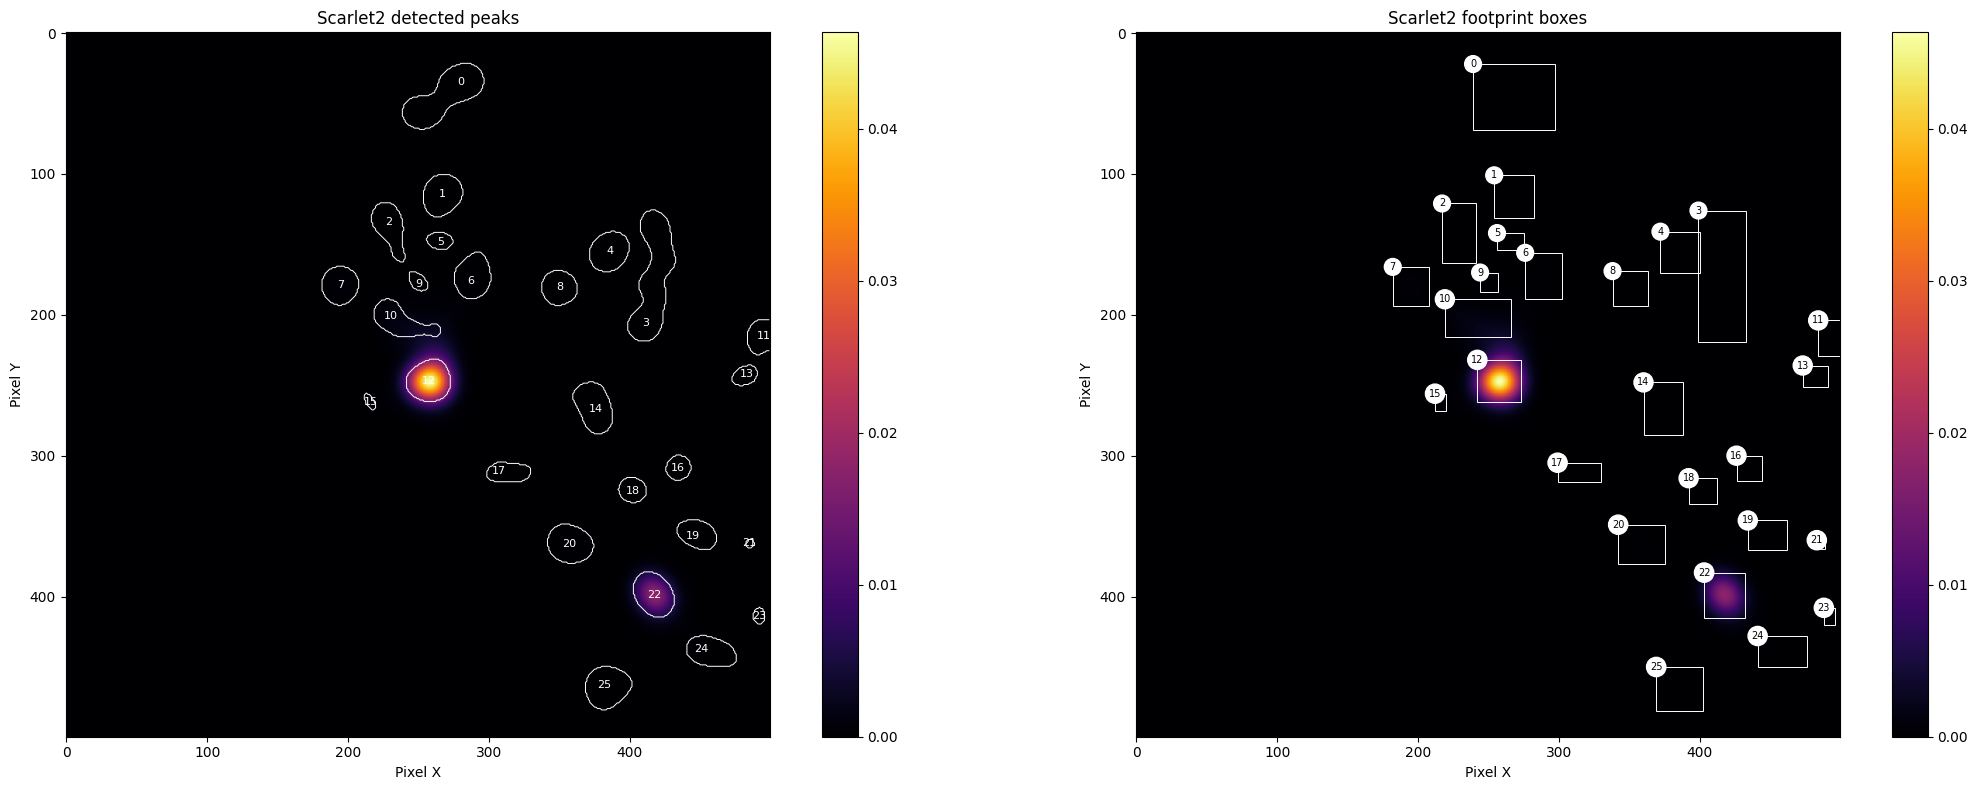

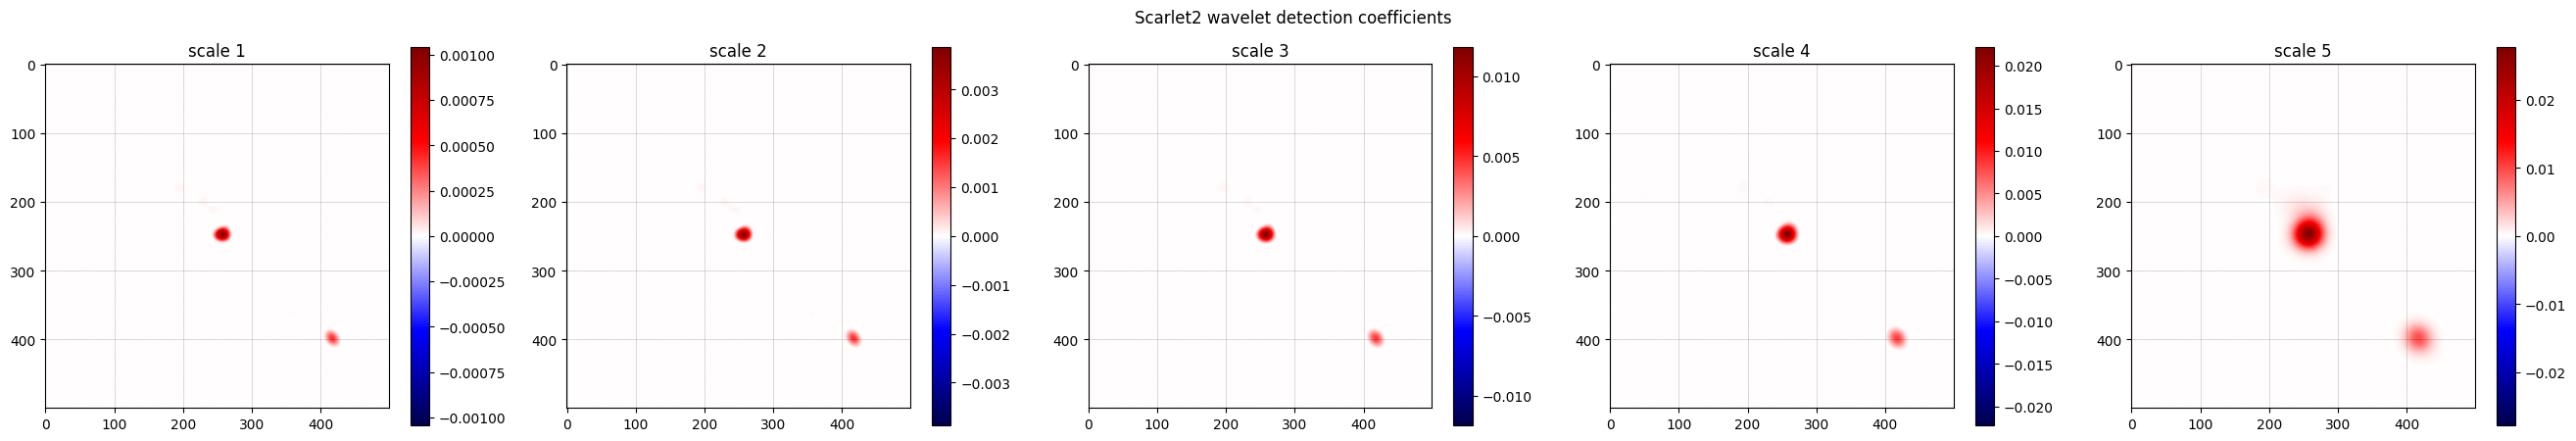

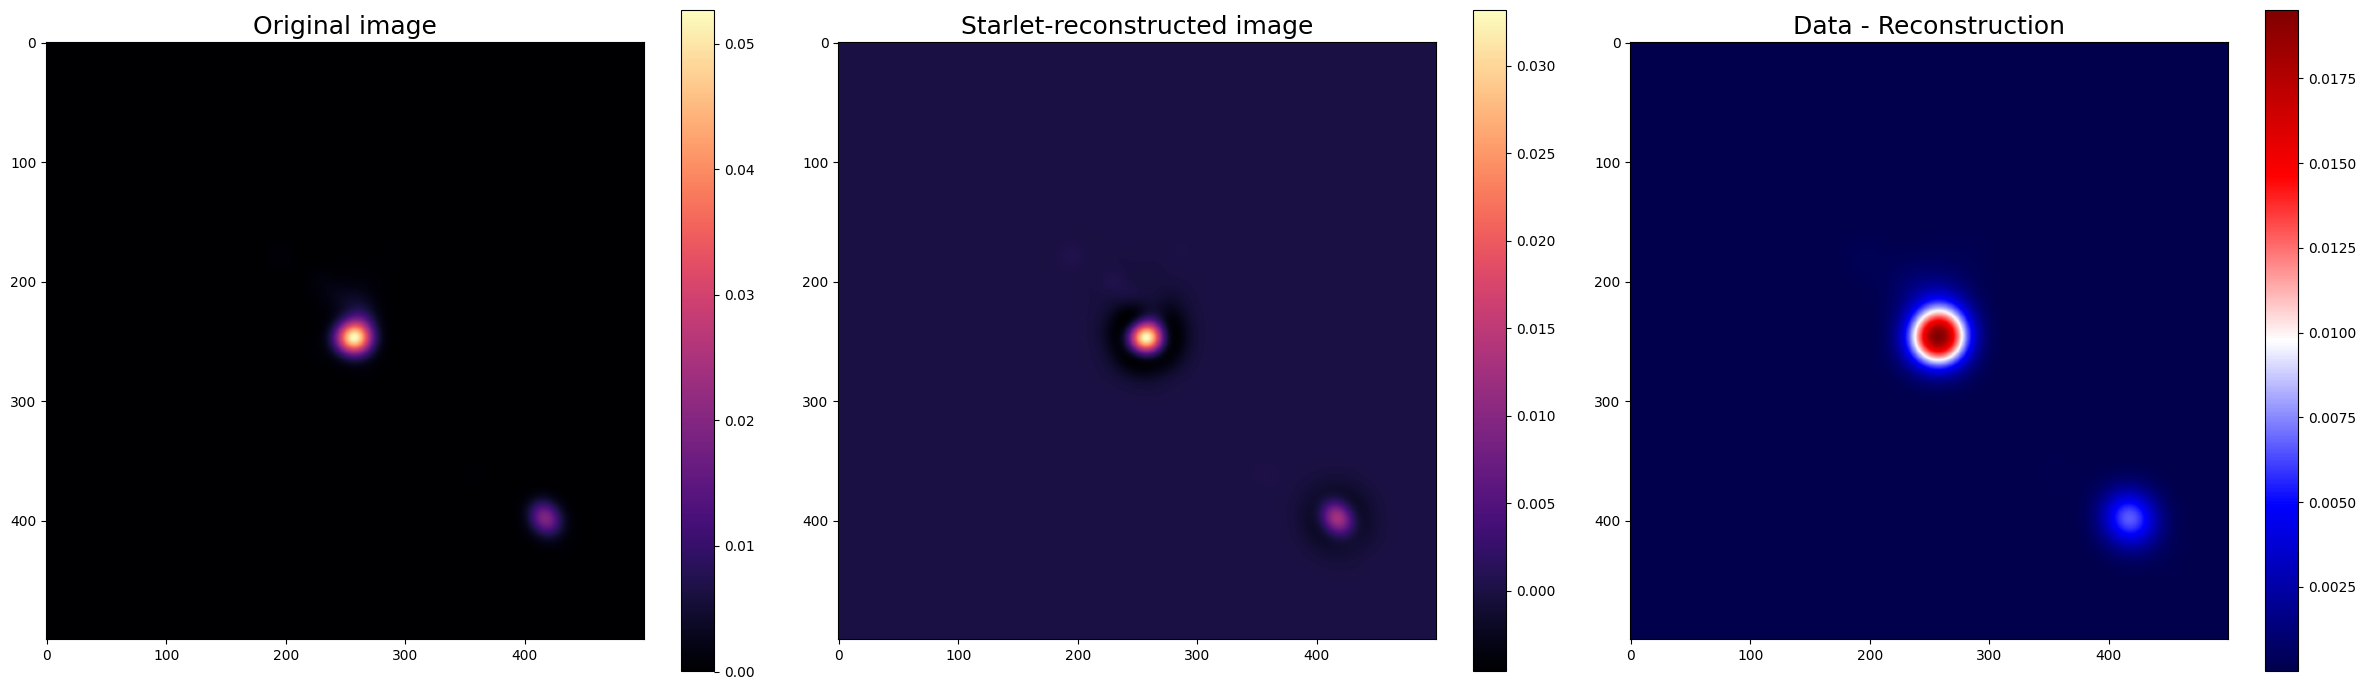

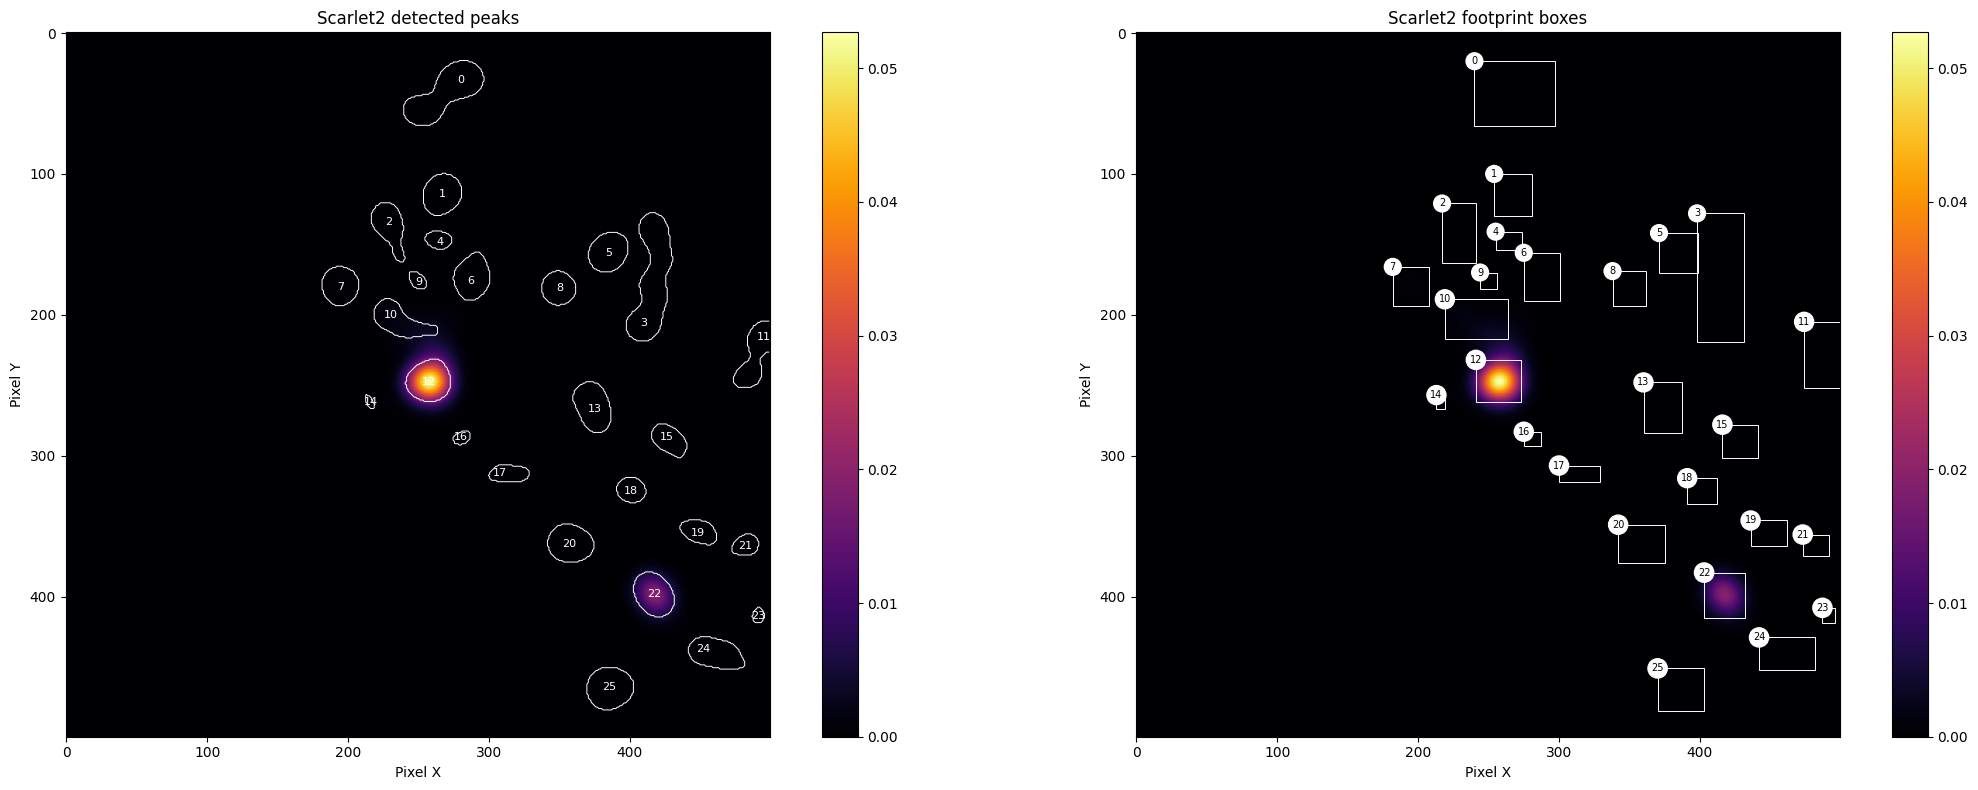

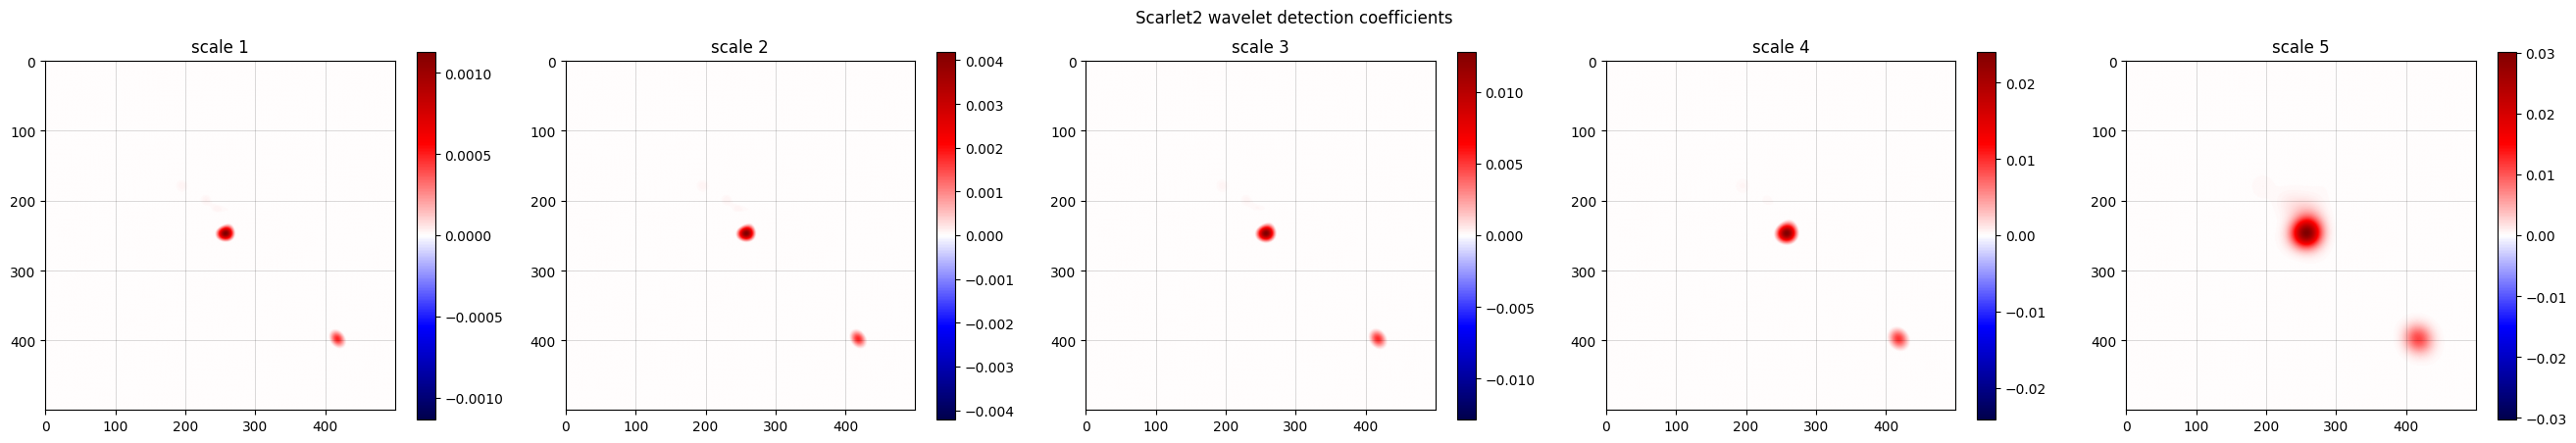

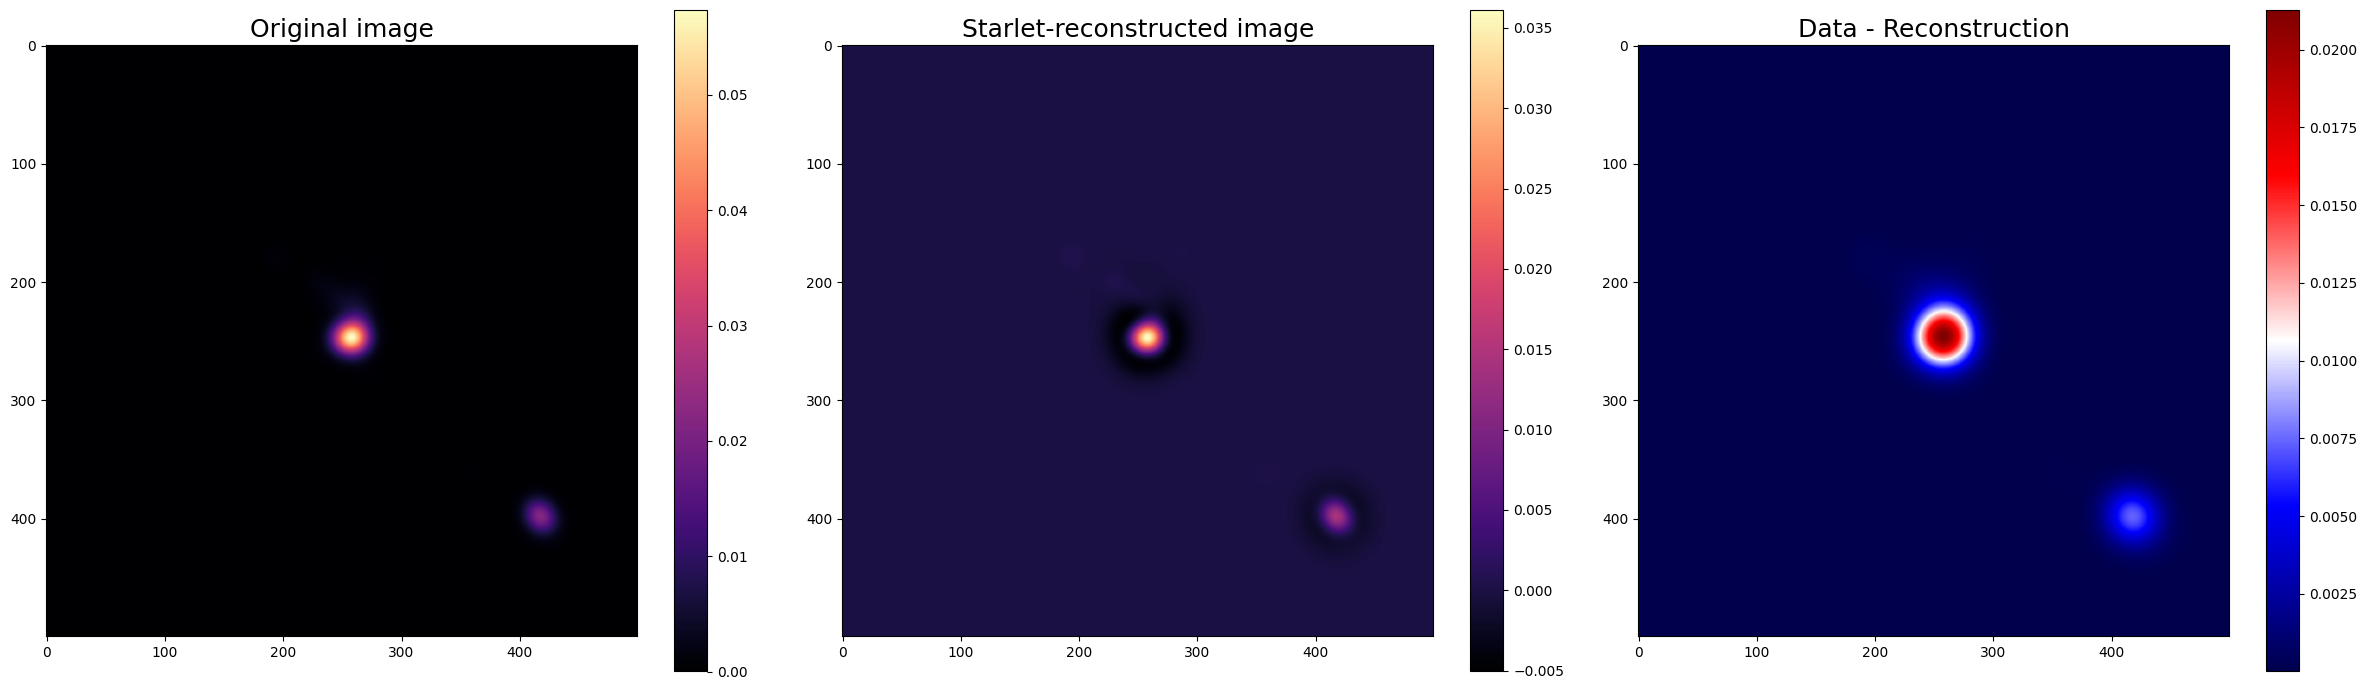

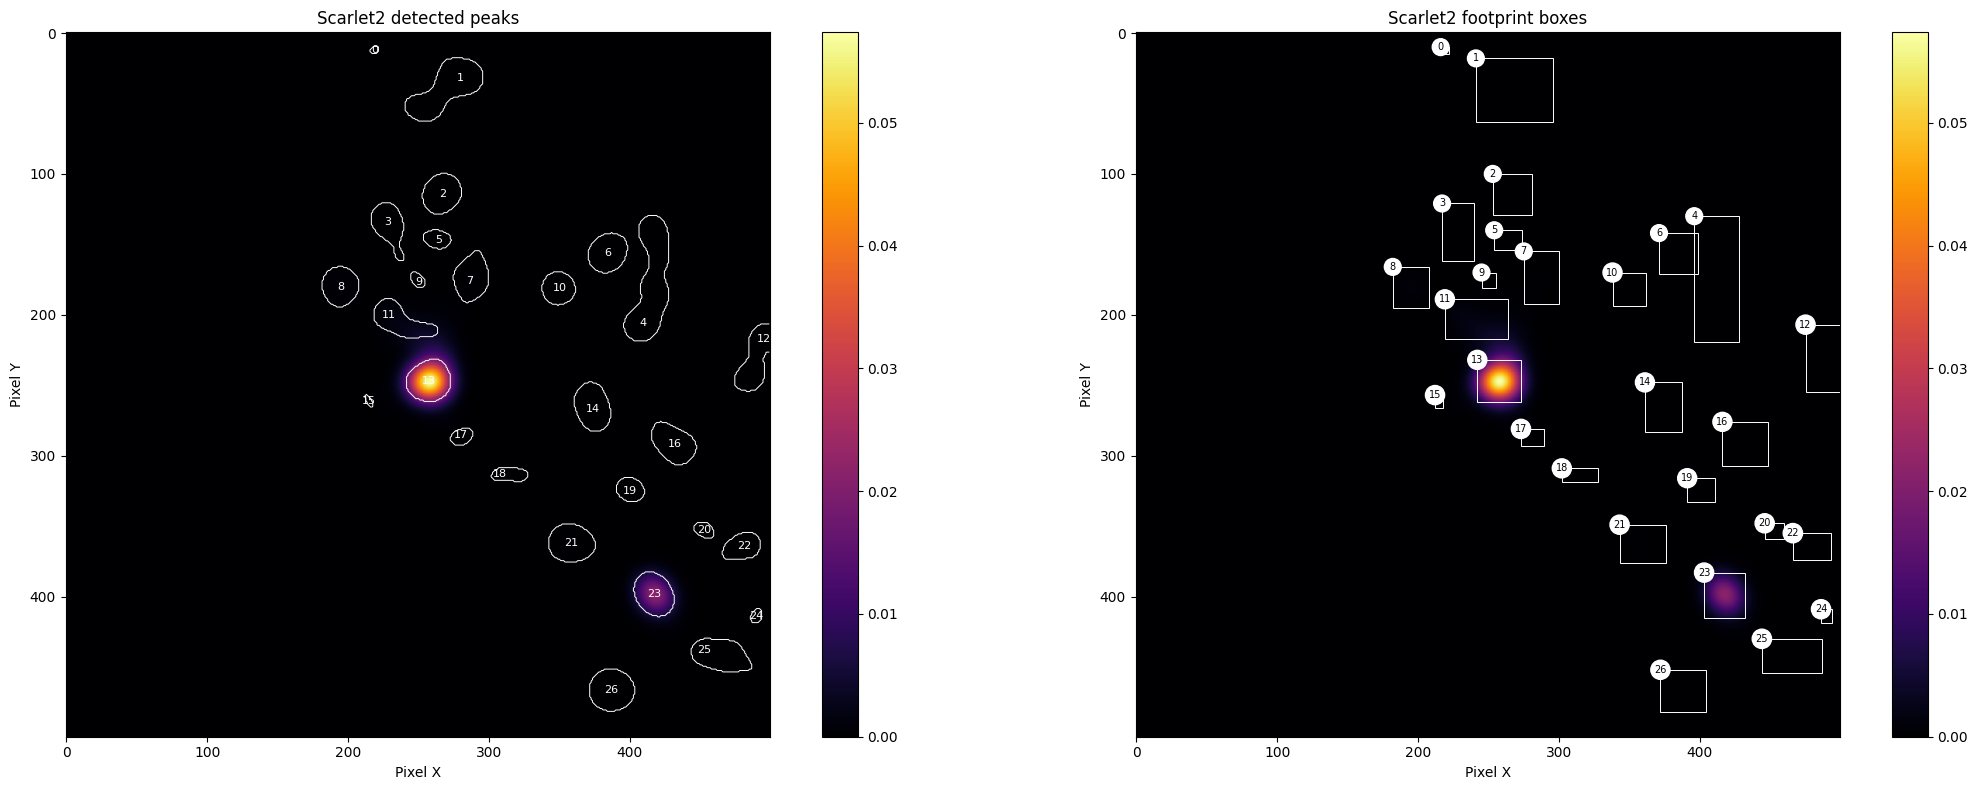

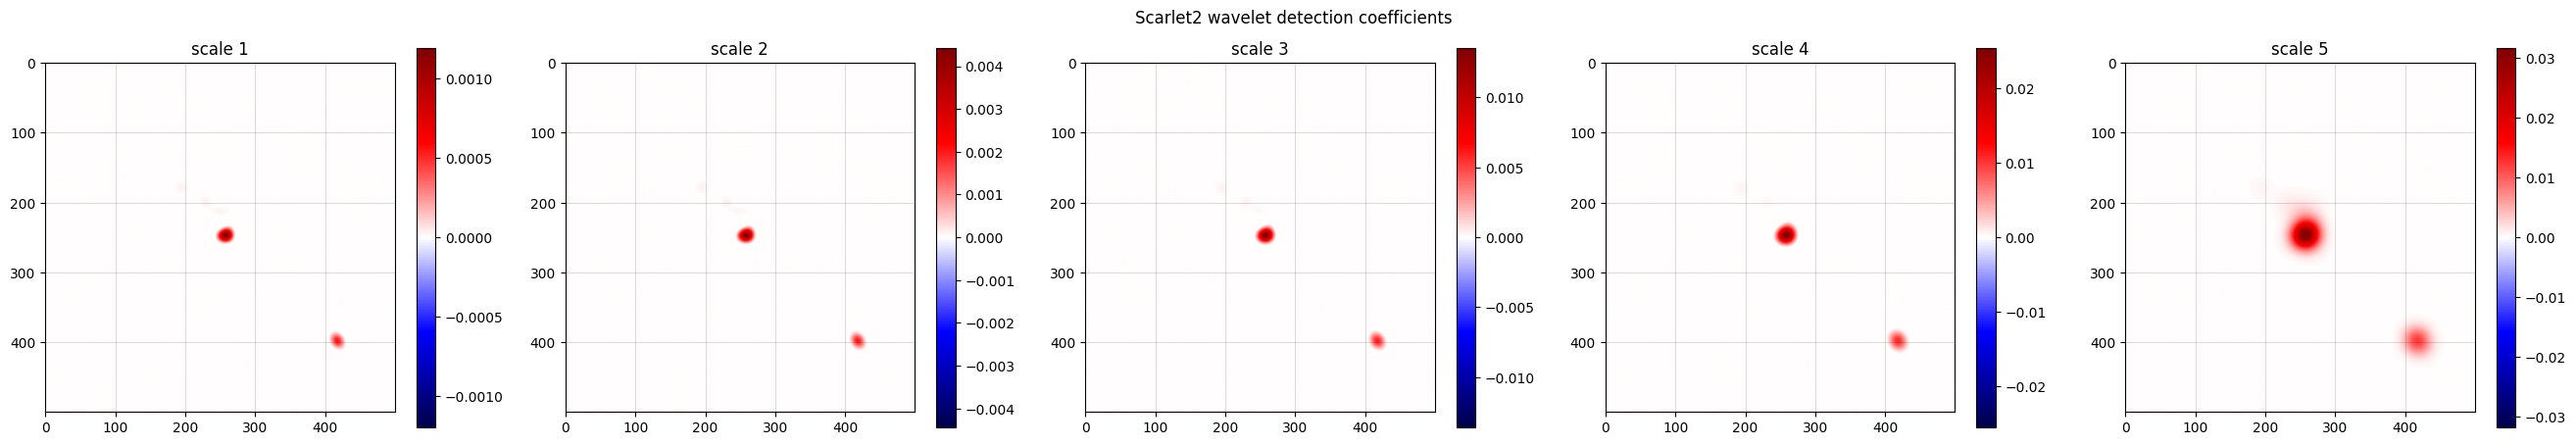

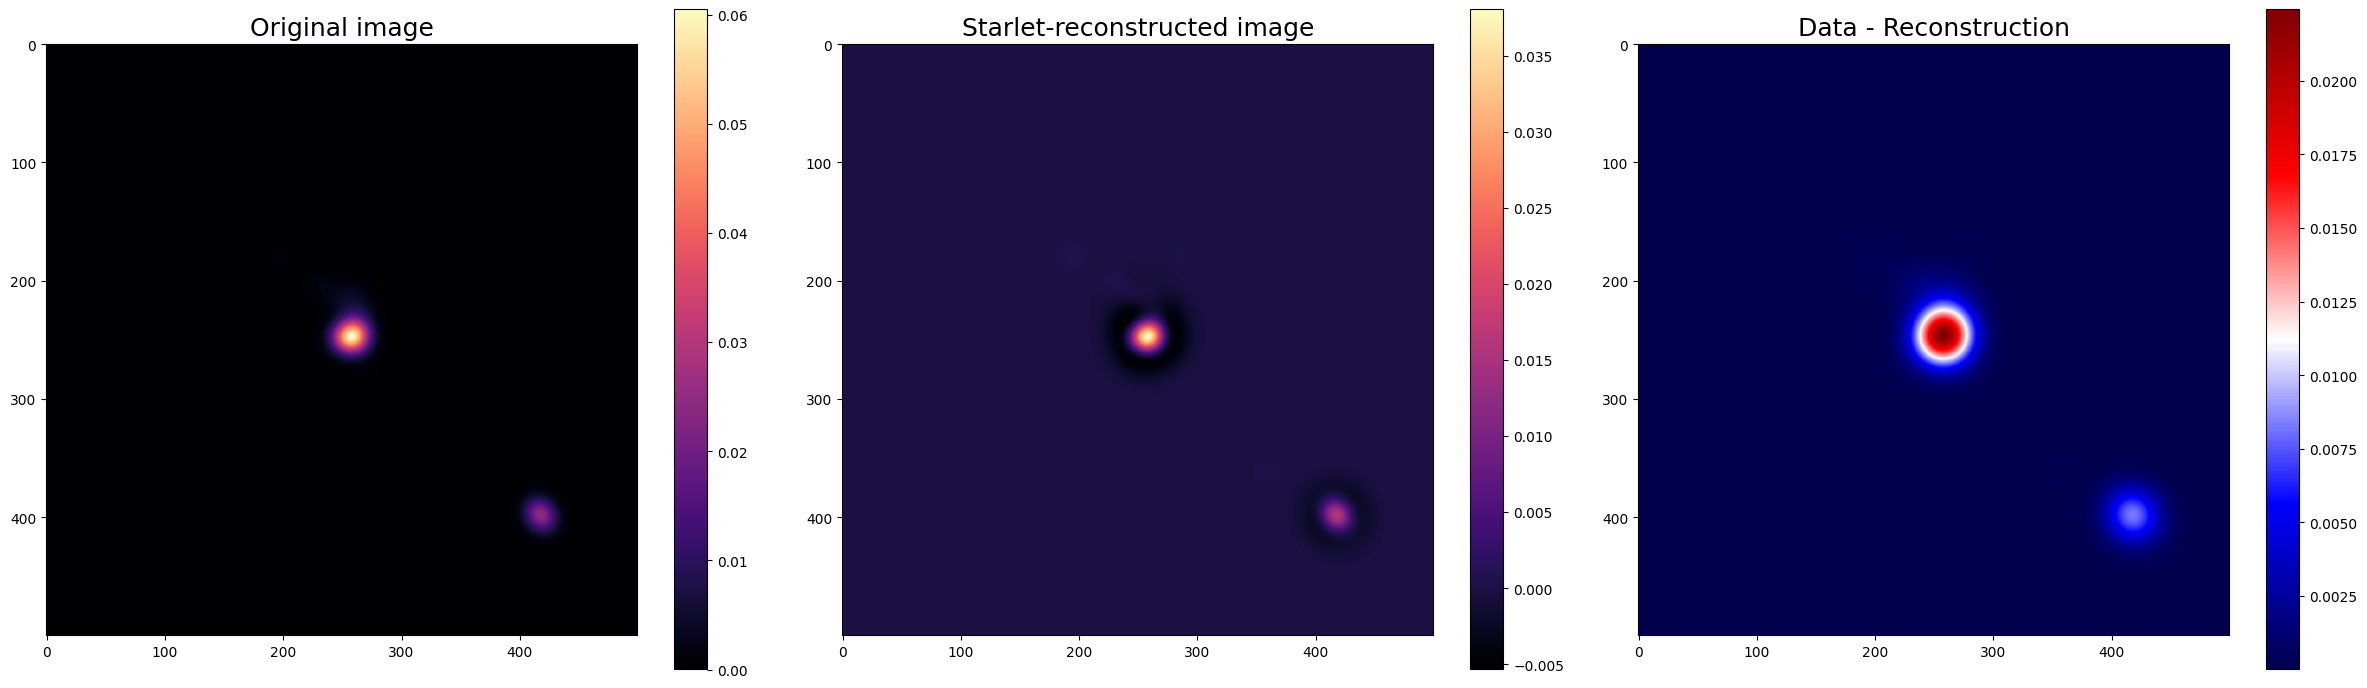

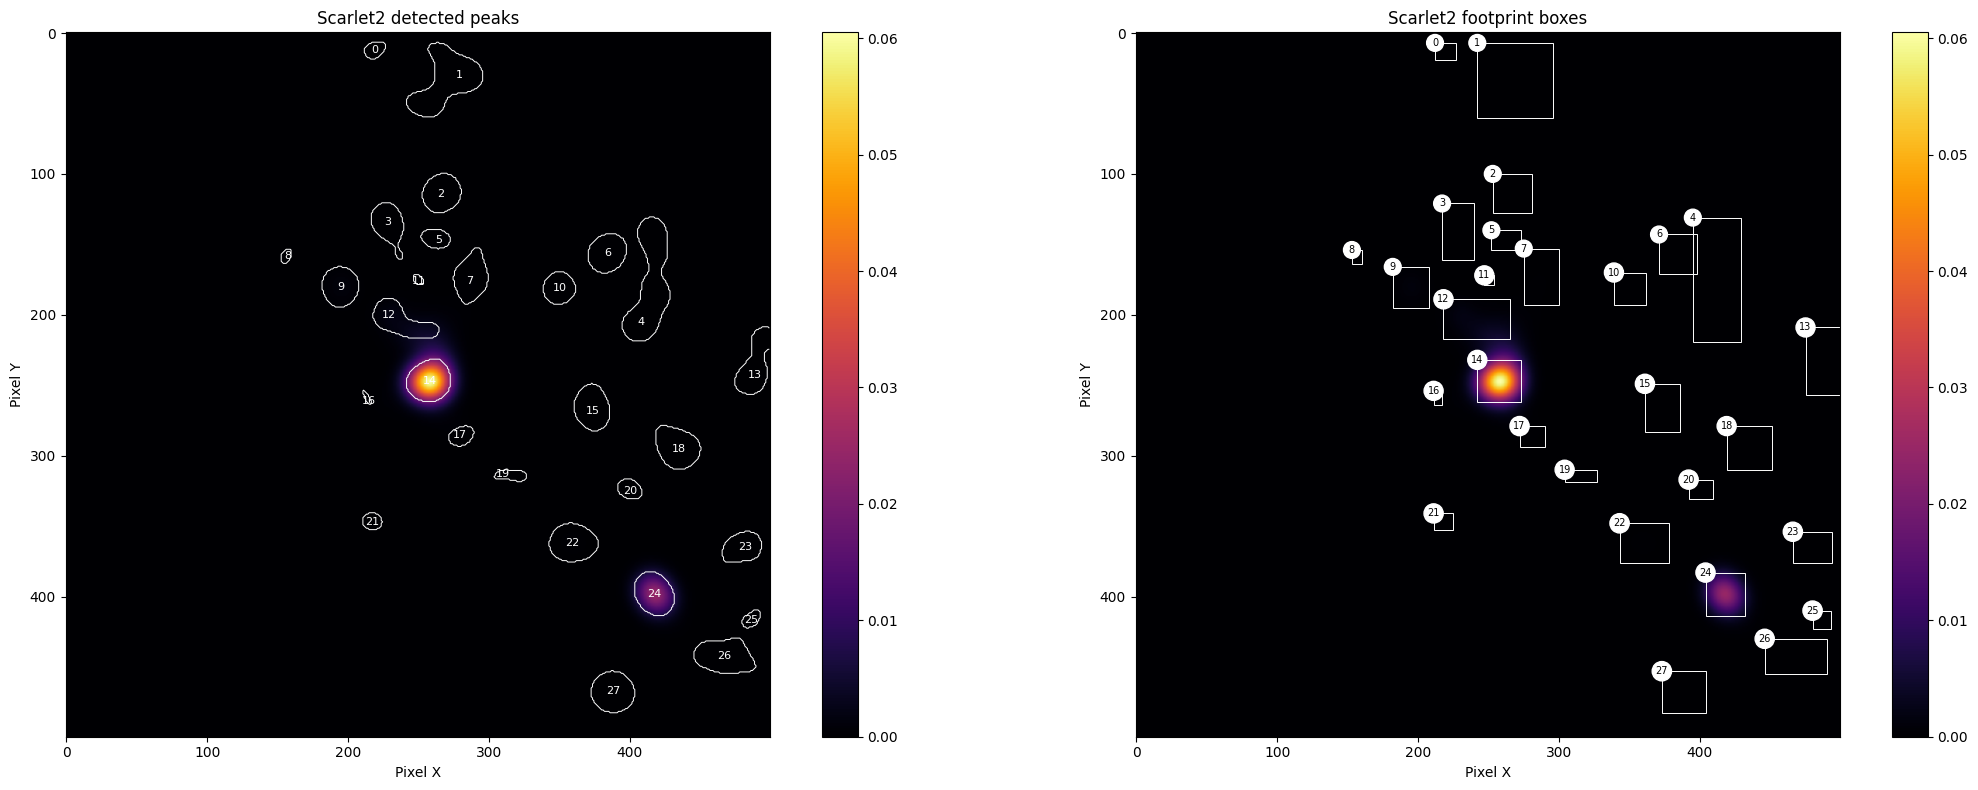

In [21]:
import matplotlib.pyplot as plt
import matplotlib

sigs = []
for i in range(70,75,1):
    detect_image = cube[i]

    detect, coeffs, footprint_img, footprint_masks, peaks, boxes = wavelet_footprints_scarlet2(
        detect_image,
        scales=4,
        k_sigma=300,
        use_scale=3,
        min_area=10,
        thresh=0.0,
    )

    lvl = detect.shape[0]
    plt.figure(figsize=(lvl * 4.5 + 4, 4.5))
    plt.suptitle('Scarlet2 wavelet detection coefficients')
    for i in range(lvl):
        plt.subplot(1, lvl, i + 1)
        plt.title('scale ' + str(i + 1))
        img = np.arcsinh(10 * detect[i]) / 10
        vmax = np.max(np.abs(img)) if np.max(np.abs(img)) > 0 else 1.0
        plt.imshow(img, cmap='seismic', vmin=-vmax, vmax=vmax)
        plt.colorbar()
        plt.grid(color='black', linewidth=0.5, alpha=0.2)
    plt.tight_layout()
    plt.show()

    reconstruction = sc.wavelets.starlet_reconstruction(coeffs)
    residual = detect_image - reconstruction

    plt.figure(figsize=(24, 7))
    plt.subplot(131)
    plt.title('Original image', fontsize=18)
    plt.imshow(detect_image, cmap='magma')
    plt.colorbar()
    plt.subplot(132)
    plt.title('Starlet-reconstructed image', fontsize=18)
    plt.imshow(reconstruction, cmap='magma')
    plt.colorbar()
    plt.subplot(133)
    plt.title('Data - Reconstruction', fontsize=18)
    plt.imshow(residual, cmap='seismic')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
    im0 = ax[0].imshow(detect_image, cmap='inferno')
    fig.colorbar(im0, ax=ax[0])
    for mask in footprint_masks:
        ax[0].contour(mask.astype(float), [0.5], colors='w', linewidths=0.7)
    for k, (yy, xx) in enumerate(peaks):
        ax[0].text(xx, yy, str(k), color='w', ha='center', va='center', size=8)
    ax[0].set_title('Scarlet2 detected peaks')
    ax[0].set_xlabel('Pixel X')
    ax[0].set_ylabel('Pixel Y')

    im1 = ax[1].imshow(detect_image, cmap='inferno')
    fig.colorbar(im1, ax=ax[1])
    for k, (y0, x0, y1, x1) in enumerate(boxes):
        rect = matplotlib.patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=0.7, edgecolor='white', facecolor='none')
        ax[1].add_patch(rect)
        ax[1].text(x0, y0, k, ha='center', va='center', size=7, bbox=dict(boxstyle='circle,pad=0.35', fc='white', ec='white', lw=1))
    ax[1].set_title('Scarlet2 footprint boxes')
    ax[1].set_xlabel('Pixel X')
    ax[1].set_ylabel('Pixel Y')
    plt.tight_layout()
    plt.show()

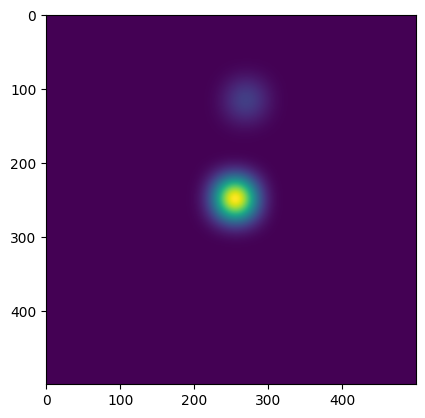

In [29]:
plt.imshow(sigs[4])

## Data structures: SourceRegion and CubeDetections

In [10]:
class SourceRegion(NamedTuple):
    y: float           # sub-pixel centroid (row)
    x: float           # sub-pixel centroid (col)
    flux: float        # sum of original flux within footprint
    snr: float         # peak significance / global significance max
    area_px: int       # footprint size in pixels
    mask: np.ndarray   # (H, W) bool — full-image footprint mask


class CubeDetections:
    """Container for per-channel detection results.

    Sources are detected once on the max-collapsed significance map (N global blobs).
    Per-channel, each source's flux and centroid are measured within its Voronoi territory.
    """

    def __init__(
        self,
        global_sources: list[SourceRegion],
        channel_regions: list[list[SourceRegion]],  # [ch_idx][src_idx]
        significance: np.ndarray,       # (n_proc_ch, H, W) float32
        diffuse_maps: np.ndarray,        # (n_proc_ch, H, W) float32
        global_significance: np.ndarray, # (H, W) float32 — max across channels
        channel_list: list[int],
        cube_shape: tuple[int, int, int],
    ) -> None:
        self.global_sources = global_sources
        self.channel_regions = channel_regions
        self.significance = significance
        self.diffuse_maps = diffuse_maps
        self.global_significance = global_significance
        self.channel_list = channel_list
        self.cube_shape = cube_shape

    def n_sources(self) -> int:
        return len(self.global_sources)

    def n_channels(self) -> int:
        return len(self.channel_list)

    def total_detections(self) -> int:
        return sum(len(r) for r in self.channel_regions)

    def n_per_channel(self) -> list[int]:
        return [len(r) for r in self.channel_regions]

    def union_mask(self, ch_idx: int) -> np.ndarray:
        """Boolean union of all source masks for a processed channel index."""
        _, H, W = self.cube_shape
        m = np.zeros((H, W), dtype=bool)
        for reg in self.channel_regions[ch_idx]:
            m |= reg.mask
        return m

## Global cube detection (`detect_cube`)

In [11]:
def detect_cube(
    cube: np.ndarray,
    channel_list: list[int] | None = None,
    n_scales: int = 5,
    k_sigma: float = 3.0,
    min_area: int = 9,
    max_area: int | None = None,
    detail_scales: tuple[int, ...] = (0, 1, 2),
    subtract_diffuse: bool = True,
    peak_min_distance: int = 20,
    peak_threshold_rel: float = 0.05,
    log=None,
) -> CubeDetections:
    """Detect sources globally via peak finding, then measure per channel.

    Steps
    -----
    1. Per-channel significance maps (fine starlet scales above diffuse).
    2. Max-project → global significance map.
    3. peak_local_max → N peaks, one per distinct source.
    4. Voronoi assignment → N spatial territories.
    5. Per channel: keep connected component at global peak within territory.
       If peak pixel not significant → non-detection (flux=0) for that channel.
    """
    from skimage.feature import peak_local_max
    from scipy.ndimage import binary_dilation as _dilate

    n_ch, H, W = cube.shape
    if channel_list is None:
        channel_list = list(range(n_ch))
    n_proc = len(channel_list)

    # ── Step 1: per-channel significance + diffuse ─────────────────────────
    sig_maps  = np.zeros((n_proc, H, W), dtype=np.float32)
    diff_maps = np.zeros((n_proc, H, W), dtype=np.float32)
    for idx, ch in enumerate(channel_list):
        diff, sig = significance_slice(
            cube[ch], n_scales=n_scales, k_sigma=k_sigma,
            detail_scales=detail_scales, subtract_diffuse=subtract_diffuse,
        )
        sig_maps[idx]  = sig
        diff_maps[idx] = diff

    # ── Step 2: global significance = max across channels ──────────────────
    global_sig = sig_maps.max(axis=0)

    # ── Step 3: peak finding ───────────────────────────────────────────────
    peak_coords = peak_local_max(
        global_sig,
        min_distance=peak_min_distance,
        threshold_rel=peak_threshold_rel,
    )  # (N, 2) in (row, col)

    if len(peak_coords) == 0:
        return CubeDetections(
            global_sources=[], channel_regions=[[] for _ in channel_list],
            significance=sig_maps, diffuse_maps=diff_maps,
            global_significance=global_sig, channel_list=channel_list,
            cube_shape=(n_ch, H, W),
        )

    # ── Step 4: Voronoi assignment + territory masks ───────────────────────
    yy, xx = np.mgrid[:H, :W]
    dist_stack = np.stack([
        np.hypot(yy - py, xx - px) for py, px in peak_coords
    ], axis=0)
    assignment = dist_stack.argmin(axis=0)

    significant_anywhere = global_sig > 0
    territories = []
    for k in range(len(peak_coords)):
        base = significant_anywhere & (assignment == k)
        territories.append(_dilate(base, iterations=5))

    # Build global SourceRegion per peak (filter by area)
    global_sources: list[SourceRegion] = []
    for k, (py, px) in enumerate(peak_coords):
        m = territories[k] & significant_anywhere
        if m.sum() < min_area:
            continue
        if max_area is not None and m.sum() > max_area:
            continue
        global_sources.append(SourceRegion(
            y=float(py), x=float(px),
            flux=float(global_sig[m].sum()),
            snr=float(global_sig[int(py), int(px)] / (global_sig.max() + 1e-12)),
            area_px=int(m.sum()),
            mask=m,
        ))

    accepted_indices = [
        k for k, (py, px) in enumerate(peak_coords)
        if (territories[k] & significant_anywhere).sum() >= min_area
        and (max_area is None or (territories[k] & significant_anywhere).sum() <= max_area)
    ]
    territories = [territories[k] for k in accepted_indices]

    global_sources.sort(key=lambda r: -r.flux)
    order = sorted(range(len(global_sources)), key=lambda i: -global_sources[i].flux)
    global_sources = [global_sources[i] for i in order]
    territories    = [territories[i] for i in order]

    # ── Step 5: per-channel footprint ─────────────────────────────────────
    channel_regions: list[list[SourceRegion]] = []
    for idx, ch in enumerate(channel_list):
        ch_regs: list[SourceRegion] = []
        sig = sig_maps[idx]
        for src, territory in zip(global_sources, territories):
            ch_mask = territory & (sig > 0)
            if ch_mask.any():
                # Keep only the component containing the global peak
                labeled_ch, _ = nd_label(ch_mask)
                py, px = int(round(src.y)), int(round(src.x))
                peak_lbl = labeled_ch[py, px]
                ch_mask = (labeled_ch == peak_lbl) if peak_lbl > 0 else np.zeros((H, W), dtype=bool)

            if ch_mask.any():
                sig_in_ch = np.zeros((H, W), dtype=np.float32)
                sig_in_ch[ch_mask] = sig[ch_mask]
                cy, cx = center_of_mass(sig_in_ch)
                cy = float(np.clip(cy, 0, H - 1))
                cx = float(np.clip(cx, 0, W - 1))
                raw_flux = float(cube[ch][ch_mask].sum())
                peak_snr  = float(sig[ch_mask].max() / (global_sig.max() + 1e-12))
                area = int(ch_mask.sum())
            else:
                cy, cx = src.y, src.x
                raw_flux = 0.0; peak_snr = 0.0; area = 0
                ch_mask = territory  # keep territory for flow masking

            ch_regs.append(SourceRegion(
                y=cy, x=cx, flux=raw_flux, snr=peak_snr, area_px=area, mask=ch_mask,
            ))
        channel_regions.append(ch_regs)

    return CubeDetections(
        global_sources=global_sources,
        channel_regions=channel_regions,
        significance=sig_maps,
        diffuse_maps=diff_maps,
        global_significance=global_sig,
        channel_list=channel_list,
        cube_shape=(n_ch, H, W),
    )

## Run detection on cube

In [12]:
CUBE_PATH = "/mnt/home/alahiry/data/mock_ifu/processed_cubes/clean_cube.npy"

cube = load_cube(CUBE_PATH)
n_ch, H, W = cube.shape
print(f"Cube shape: {cube.shape}  flux range [{cube.min():.3e}, {cube.max():.3e}]")

channel_list = active_channels(cube, threshold_frac=0.10)
print(f"Active channels: {len(channel_list)}  (ch {channel_list[0]}–{channel_list[-1]})")

Cube shape: (200, 500, 500)  flux range [-1.966e-19, 6.891e-02]
Active channels: 138  (ch 30–167)


In [13]:
dets = detect_cube(
    cube, channel_list=channel_list,
    n_scales=5, k_sigma=5.0, min_area=9,
    detail_scales=(0, 1, 2), subtract_diffuse=True,
    peak_min_distance=30, peak_threshold_rel=0.05,
)

print(f"Global sources: {dets.n_sources()}")
for i, src in enumerate(dets.global_sources):
    print(f"  src {i}  y={src.y:.0f}  x={src.x:.0f}  area={src.area_px}px  snr={src.snr:.2f}")

Global sources: 3
  src 0  y=248  x=257  area=86886px  snr=1.00
  src 1  y=398  x=418  area=53618px  snr=0.58
  src 2  y=116  x=263  area=90875px  snr=0.25


## Quick visualisation

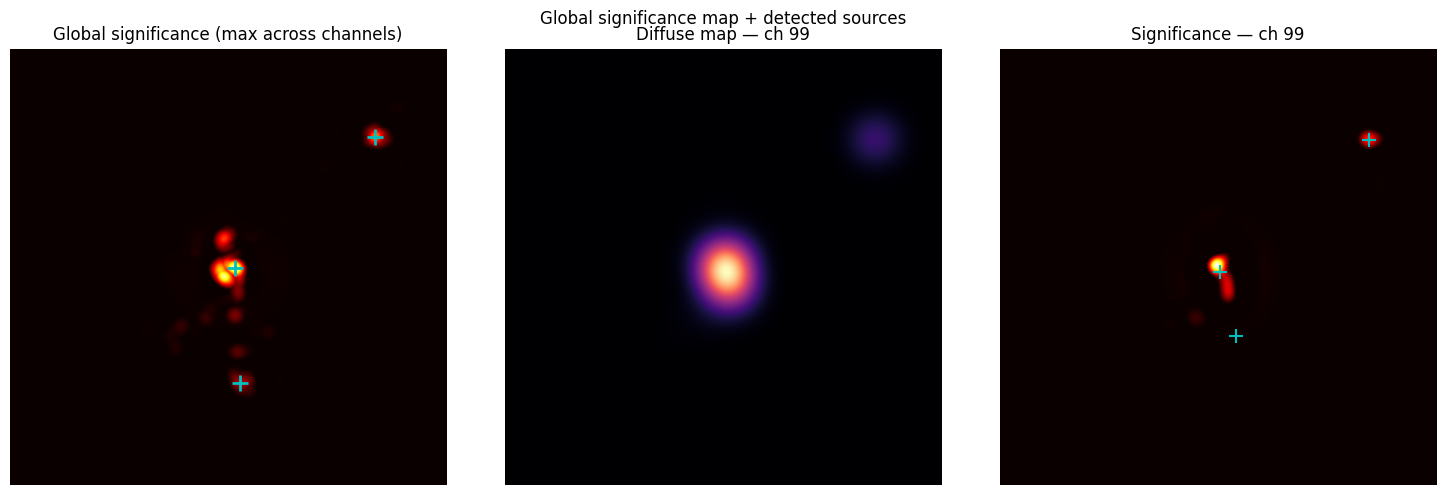

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Global significance map + detected sources", fontsize=12)

axes[0].imshow(dets.global_significance, cmap="hot", origin="lower")
axes[0].set_title("Global significance (max across channels)")
for src in dets.global_sources:
    axes[0].plot(src.x, src.y, "c+", ms=12, mew=2)

rep_idx = len(channel_list) // 2
rep_ch = channel_list[rep_idx]
axes[1].imshow(dets.diffuse_maps[rep_idx], cmap="magma", origin="lower")
axes[1].set_title(f"Diffuse map — ch {rep_ch}")

axes[2].imshow(dets.significance[rep_idx], cmap="hot", origin="lower")
axes[2].set_title(f"Significance — ch {rep_ch}")
for reg in dets.channel_regions[rep_idx]:
    axes[2].plot(reg.x, reg.y, "c+", ms=10, mew=1.5)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()